# Stacked Auto-Encoder Implementation

### 0. pip

In [1]:
# you should run this only once - uncomment before first use
%pip install pandas numpy matplotlib scikit-learn joblib tqdm
# if you want to use gpu, ensure you have cuda setup
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126


  Using cached matplotlib-3.10.3-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 6.3 MB/s eta 0:00:02
   ---------------------------------------  11.0/11.1 MB 31.3 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 28.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   -------------------- ------------------- 6.8/13.0 MB 35.0 MB/s eta 0:00

### 1. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os
from tqdm import tqdm

In [4]:
normal_data_file = 'checkpointing/normal_data_preprocessed.joblib'
attack_data_file = 'checkpointing/attack_data_preprocessed.joblib'
normal_csv_path = r'data\LMD-2023 [2.3M Elements - Normal]checked.csv'
eors_csv_path = r'data\LMD-2023 [2.3M Elements - EORS]checked.csv'
eoht_csv_path = r'data\LMD-2023 [2.3M Elements - EOHT]checked.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using device: NVIDIA GeForce RTX 4070 SUPER


### 2. Data Loading & Preprocessing

In [5]:
# Check if checkpoint files exist
if os.path.exists(normal_data_file) and os.path.exists(attack_data_file):
    print("Checkpoint files found. Loading preprocessed data...")
    X_normal_preprocessed = joblib.load(normal_data_file)
    X_attack_preprocessed = joblib.load(attack_data_file)
    print("Data loaded successfully from checkpoints.")
else:
    print("Checkpoint files not found. Running full preprocessing pipeline...")
    # Load normal and attack datasets
    try:
        df_normal = pd.read_csv(normal_csv_path)
        df_attack_eors = pd.read_csv(eors_csv_path)
        df_attack_eoht = pd.read_csv(eoht_csv_path)
        df_attack = pd.concat([df_attack_eors, df_attack_eoht], ignore_index=True)
        print(f"Loaded {len(df_normal)} normal records and {len(df_attack)} attack records")
    except FileNotFoundError:
        print("Error: one of the dataset files not found. Please check the data folder.")

    # Feature selection as per Table 2 in the paper
    selected_features = [
        'Computer', 'DestinationPortName', 'EventID', 'EventRecordID',
        'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6',
        'SystemTime'
    ]

    # Process normal data
    df_normal['SystemTime'] = pd.to_datetime(df_normal['SystemTime'])
    df_normal['SystemTime_year'] = df_normal['SystemTime'].dt.year
    df_normal['SystemTime_month'] = df_normal['SystemTime'].dt.month
    df_normal['SystemTime_week'] = df_normal['SystemTime'].dt.isocalendar().week
    df_normal['SystemTime_day'] = df_normal['SystemTime'].dt.day
    df_normal['SystemTime_hour'] = df_normal['SystemTime'].dt.hour
    df_normal['SystemTime_minute'] = df_normal['SystemTime'].dt.minute
    df_normal['SystemTime_day_of_week'] = df_normal['SystemTime'].dt.dayofweek
    
    # Process attack data
    df_attack['SystemTime'] = pd.to_datetime(df_attack['SystemTime'])
    df_attack['SystemTime_year'] = df_attack['SystemTime'].dt.year
    df_attack['SystemTime_month'] = df_attack['SystemTime'].dt.month
    df_attack['SystemTime_week'] = df_attack['SystemTime'].dt.isocalendar().week
    df_attack['SystemTime_day'] = df_attack['SystemTime'].dt.day
    df_attack['SystemTime_hour'] = df_attack['SystemTime'].dt.hour
    df_attack['SystemTime_minute'] = df_attack['SystemTime'].dt.minute
    df_attack['SystemTime_day_of_week'] = df_attack['SystemTime'].dt.dayofweek
    
    time_features = ['SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week']
    final_features = selected_features[:-1] + time_features
    
    # Select features for both datasets
    X_normal = df_normal[final_features]
    X_attack = df_attack[final_features]

    # Define feature types
    categorical_features = ['Computer', 'DestinationPortName', 'EventID', 'Initiated', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day_of_week']
    numerical_features = ['EventRecordID', 'Execution_ProcessID', 'ProcessId', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Fit preprocessor on normal data and transform both datasets
    X_normal_preprocessed = preprocessor.fit_transform(X_normal)
    X_attack_preprocessed = preprocessor.transform(X_attack)
    
    # Save the processed data
    print("Saving processed data to disk...")
    joblib.dump(X_normal_preprocessed, normal_data_file)
    joblib.dump(X_attack_preprocessed, attack_data_file)
    print("Checkpoint files saved successfully.")

# Split normal data into train and test sets
X_train, X_test = train_test_split(
    X_normal_preprocessed, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Attack data size: {X_attack_preprocessed.shape[0]}")


Checkpoint files not found. Running full preprocessing pipeline...


C:\Users\broyd\AppData\Local\Temp\ipykernel_13732\3899460992.py:11: DtypeWarning: Columns (39,52,55,56,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df_normal = pd.read_csv(normal_csv_path)
C:\Users\broyd\AppData\Local\Temp\ipykernel_13732\3899460992.py:12: DtypeWarning: Columns (39,40,41,42,43,44,46,47,48,49,51,52,57,58,59,60,70,71,73,74,75,76,77,78,80,81,82,83,84,86,87,88,90,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attack_eors = pd.read_csv(eors_csv_path)
C:\Users\broyd\AppData\Local\Temp\ipykernel_13732\3899460992.py:13: DtypeWarning: Columns (39,52,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attack_eoht = pd.read_csv(eoht_csv_path)


Loaded 1632903 normal records and 511105 attack records
Saving processed data to disk...
Checkpoint files saved successfully.
Training set size: 1306322
Test set size: 326581
Attack data size: 511105


### 3. Stacked Auto-Encoder Architecture

In [16]:
class StackedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(StackedAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.BatchNorm1d(50),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(50, 30),
            nn.BatchNorm1d(30),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(30, 20),
            nn.BatchNorm1d(20),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(20, 10),
            nn.BatchNorm1d(10),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(10, 5), # Latent space
            nn.ReLU(inplace=True)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(5, 10),
            nn.BatchNorm1d(10),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(10, 20),
            nn.BatchNorm1d(20),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(20, 30),
            nn.BatchNorm1d(30),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(30, 50),
            nn.BatchNorm1d(50),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(50, input_dim),
            nn.Sigmoid() # To output values between 0 and 1
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Get input dimension from preprocessed data
input_dim = X_train.shape[1]
model = StackedAutoencoder(input_dim)
print(model)

StackedAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=71, out_features=50, bias=True)
    (1): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=50, out_features=30, bias=True)
    (4): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=20, out_features=10, bias=True)
    (10): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=10, out_features=5, bias=True)
    (13): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track

### 4. Training

In [17]:
# Use only training data for training the autoencoder
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)

# Move model to device
model = model.to(device)

# Hyperparameters
batch_size = 50
epochs = 20
learning_rate = 1e-3
weight_decay = 1e-5

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop with tqdm for epochs only
for epoch in tqdm(range(epochs), desc="Training Epochs"):
    running_loss = 0.0
    
    for batch_idx, data in enumerate(train_loader):
        inputs, _ = data
        inputs = inputs.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')
    
    # Save the entire model after each epoch
    torch.save(model, "checkpointing/final_model.pth")
    print(f"Model saved after epoch {epoch+1}")

print("Training completed. Final model saved.")

Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Batch [1000/26127], Loss: 0.0800
Epoch [1/20], Batch [2000/26127], Loss: 0.0669
Epoch [1/20], Batch [3000/26127], Loss: 0.0648
Epoch [1/20], Batch [4000/26127], Loss: 0.0532
Epoch [1/20], Batch [5000/26127], Loss: 0.0491
Epoch [1/20], Batch [6000/26127], Loss: 0.0459
Epoch [1/20], Batch [7000/26127], Loss: 0.0441
Epoch [1/20], Batch [8000/26127], Loss: 0.0417
Epoch [1/20], Batch [9000/26127], Loss: 0.0467
Epoch [1/20], Batch [10000/26127], Loss: 0.0529
Epoch [1/20], Batch [11000/26127], Loss: 0.0397
Epoch [1/20], Batch [12000/26127], Loss: 0.0421
Epoch [1/20], Batch [13000/26127], Loss: 0.0437
Epoch [1/20], Batch [14000/26127], Loss: 0.0399
Epoch [1/20], Batch [15000/26127], Loss: 0.0410
Epoch [1/20], Batch [16000/26127], Loss: 0.0431
Epoch [1/20], Batch [17000/26127], Loss: 0.0356
Epoch [1/20], Batch [18000/26127], Loss: 0.0378
Epoch [1/20], Batch [19000/26127], Loss: 0.0381
Epoch [1/20], Batch [20000/26127], Loss: 0.0399
Epoch [1/20], Batch [21000/26127], Loss: 0.0330
E

Training Epochs:   5%|▌         | 1/20 [01:31<29:06, 91.94s/it]

Epoch [1/20], Average Loss: 0.0489
Model saved after epoch 1
Epoch [2/20], Batch [1000/26127], Loss: 0.0367
Epoch [2/20], Batch [2000/26127], Loss: 0.0369
Epoch [2/20], Batch [3000/26127], Loss: 0.0438
Epoch [2/20], Batch [4000/26127], Loss: 0.0445
Epoch [2/20], Batch [5000/26127], Loss: 0.0313
Epoch [2/20], Batch [6000/26127], Loss: 0.0382
Epoch [2/20], Batch [7000/26127], Loss: 0.0346
Epoch [2/20], Batch [8000/26127], Loss: 0.0315
Epoch [2/20], Batch [9000/26127], Loss: 0.0324
Epoch [2/20], Batch [10000/26127], Loss: 0.0341
Epoch [2/20], Batch [11000/26127], Loss: 0.0349
Epoch [2/20], Batch [12000/26127], Loss: 0.0318
Epoch [2/20], Batch [13000/26127], Loss: 0.0328
Epoch [2/20], Batch [14000/26127], Loss: 0.0359
Epoch [2/20], Batch [15000/26127], Loss: 0.0323
Epoch [2/20], Batch [16000/26127], Loss: 0.0343
Epoch [2/20], Batch [17000/26127], Loss: 0.0319
Epoch [2/20], Batch [18000/26127], Loss: 0.0328
Epoch [2/20], Batch [19000/26127], Loss: 0.0352
Epoch [2/20], Batch [20000/26127], L

Training Epochs:  10%|█         | 2/20 [03:09<28:30, 95.01s/it]

...

Epoch [18/20], Average Loss: 0.0288
Model saved after epoch 18
Epoch [19/20], Batch [1000/26127], Loss: 0.0277
Epoch [19/20], Batch [2000/26127], Loss: 0.0287
Epoch [19/20], Batch [3000/26127], Loss: 0.0296
Epoch [19/20], Batch [4000/26127], Loss: 0.0311
Epoch [19/20], Batch [5000/26127], Loss: 0.0299
Epoch [19/20], Batch [6000/26127], Loss: 0.0300
Epoch [19/20], Batch [7000/26127], Loss: 0.0274
Epoch [19/20], Batch [8000/26127], Loss: 0.0295
Epoch [19/20], Batch [9000/26127], Loss: 0.0279
Epoch [19/20], Batch [10000/26127], Loss: 0.0260
Epoch [19/20], Batch [11000/26127], Loss: 0.0289
Epoch [19/20], Batch [12000/26127], Loss: 0.0289
Epoch [19/20], Batch [13000/26127], Loss: 0.0280
Epoch [19/20], Batch [14000/26127], Loss: 0.0287
Epoch [19/20], Batch [15000/26127], Loss: 0.0282
Epoch [19/20], Batch [16000/26127], Loss: 0.0305
Epoch [19/20], Batch [17000/26127], Loss: 0.0281
Epoch [19/20], Batch [18000/26127], Loss: 0.0286
Epoch [19/20], Batch [19000/26127], Loss: 0.0280
Epoch [19/20], 

Training Epochs:  95%|█████████▌| 19/20 [28:53<01:28, 88.12s/it]

Epoch [19/20], Average Loss: 0.0287
Model saved after epoch 19
Epoch [20/20], Batch [1000/26127], Loss: 0.0308
Epoch [20/20], Batch [2000/26127], Loss: 0.0291
Epoch [20/20], Batch [3000/26127], Loss: 0.0282
Epoch [20/20], Batch [4000/26127], Loss: 0.0270
Epoch [20/20], Batch [5000/26127], Loss: 0.0296
Epoch [20/20], Batch [6000/26127], Loss: 0.0277
Epoch [20/20], Batch [7000/26127], Loss: 0.0269
Epoch [20/20], Batch [8000/26127], Loss: 0.0282
Epoch [20/20], Batch [9000/26127], Loss: 0.0297
Epoch [20/20], Batch [10000/26127], Loss: 0.0278
Epoch [20/20], Batch [11000/26127], Loss: 0.0277
Epoch [20/20], Batch [12000/26127], Loss: 0.0276
Epoch [20/20], Batch [13000/26127], Loss: 0.0271
Epoch [20/20], Batch [14000/26127], Loss: 0.0263
Epoch [20/20], Batch [15000/26127], Loss: 0.0281
Epoch [20/20], Batch [16000/26127], Loss: 0.0292
Epoch [20/20], Batch [17000/26127], Loss: 0.0274
Epoch [20/20], Batch [18000/26127], Loss: 0.0287
Epoch [20/20], Batch [19000/26127], Loss: 0.0271
Epoch [20/20], 

Training Epochs: 100%|██████████| 20/20 [30:20<00:00, 91.01s/it]

Epoch [20/20], Average Loss: 0.0288
Model saved after epoch 20
Training completed. Final model saved.


### 5. Evaluation

In [18]:
# Load the model
loaded_model = torch.load("checkpointing/final_model.pth", weights_only=False).to(device)
model = loaded_model 

# Convert test and attack data to tensors
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32).to(device)
X_attack_tensor = torch.tensor(X_attack_preprocessed.toarray(), dtype=torch.float32).to(device)

# Calculate reconstruction errors for test data (unseen normal data)
model.eval() # Set the model to evaluation mode
with torch.no_grad():
    reconstructions_test = model(X_test_tensor)
    mse_test = nn.MSELoss(reduction='none')(reconstructions_test, X_test_tensor)
    test_errors = torch.mean(mse_test, dim=1)

# Calculate reconstruction errors for attack data
with torch.no_grad():
    reconstructions_attack = model(X_attack_tensor)
    mse_attack = nn.MSELoss(reduction='none')(reconstructions_attack, X_attack_tensor)
    attack_errors = torch.mean(mse_attack, dim=1)

print(f"\nAverage reconstruction error for test normal data: {torch.mean(test_errors):.4f}")
print(f"Average reconstruction error for attack data: {torch.mean(attack_errors):.4f}")

# Determine threshold based on test data (99th percentile)
threshold = np.percentile(test_errors.cpu().numpy(), 99) # Move to CPU for numpy operations
print(f"Threshold for anomaly detection: {threshold:.4f}")

# Evaluate on attack data
predictions_attack = (attack_errors.cpu().numpy() > threshold)
accuracy_attack = np.sum(predictions_attack) / len(attack_errors)
print(f"Anomalies correctly detected in attack data: {np.sum(predictions_attack)} / {len(attack_errors)} ({accuracy_attack:.2%})")

# Evaluate on test normal data
predictions_test = (test_errors.cpu().numpy() > threshold)
false_positive_rate = np.sum(predictions_test) / len(test_errors) 
print(f"False positives in test normal data: {np.sum(predictions_test)} / {len(test_errors)} ({false_positive_rate:.2%})")


Average reconstruction error for test normal data: 0.0006
Average reconstruction error for attack data: 0.0686
Threshold for anomaly detection: 0.0040
Anomalies correctly detected in attack data: 497645 / 511105 (97.37%)
False positives in test normal data: 3266 / 326581 (1.00%)


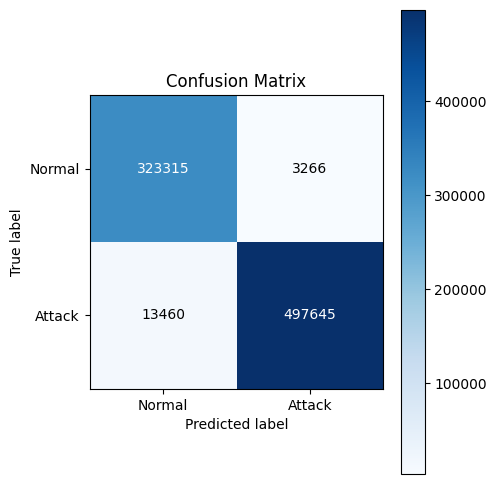

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# true labels: 0 for normal, 1 for attack
y_true = np.concatenate([
    np.zeros(len(predictions_test), dtype=int),
    np.ones(len(predictions_attack), dtype=int)
])
# predicted labels: cast booleans to int
y_pred = np.concatenate([
    predictions_test.astype(int),
    predictions_attack.astype(int)
])

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.figure.colorbar(im, ax=ax)
classes = ['Normal', 'Attack']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')

# annotate counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()